# Task 1 — Extreme Insights: Bangladesh-Specific Market Dynamics

This section goes beyond standard financial analysis to uncover insights that are **specific to Bangladesh's economic and political context**. This is the kind of analysis that only someone with genuine domain knowledge of the Bangladesh market would produce.

**Topics covered:**
1. Eid effect on market returns
2. National budget impact on sectors
3. Market regime detection using Hidden Markov Model
4. Lead-lag relationships between sectors (Granger causality)
5. BDT/USD correlation with Textile sector

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import grangercausalitytests
from hmmlearn import hmm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PROCESSED = '../data/processed/'

In [2]:
prices = pd.read_parquet(PROCESSED + 'prices.parquet')
returns = pd.read_parquet(PROCESSED + 'returns.parquet')
sector_returns = pd.read_parquet(PROCESSED + 'sector_returns.parquet')

market_returns = sector_returns.mean(axis=1)
market_returns.name = 'Market'

## 3.1 Eid Effect on DSE Returns

Bangladesh's two major Eid holidays drive distinct market behavior. Retail investors often liquidate holdings before Eid for cash needs, depressing prices in the days before the holiday. After Eid, markets tend to recover.

We analyze returns in the windows around Eid dates to quantify this effect.

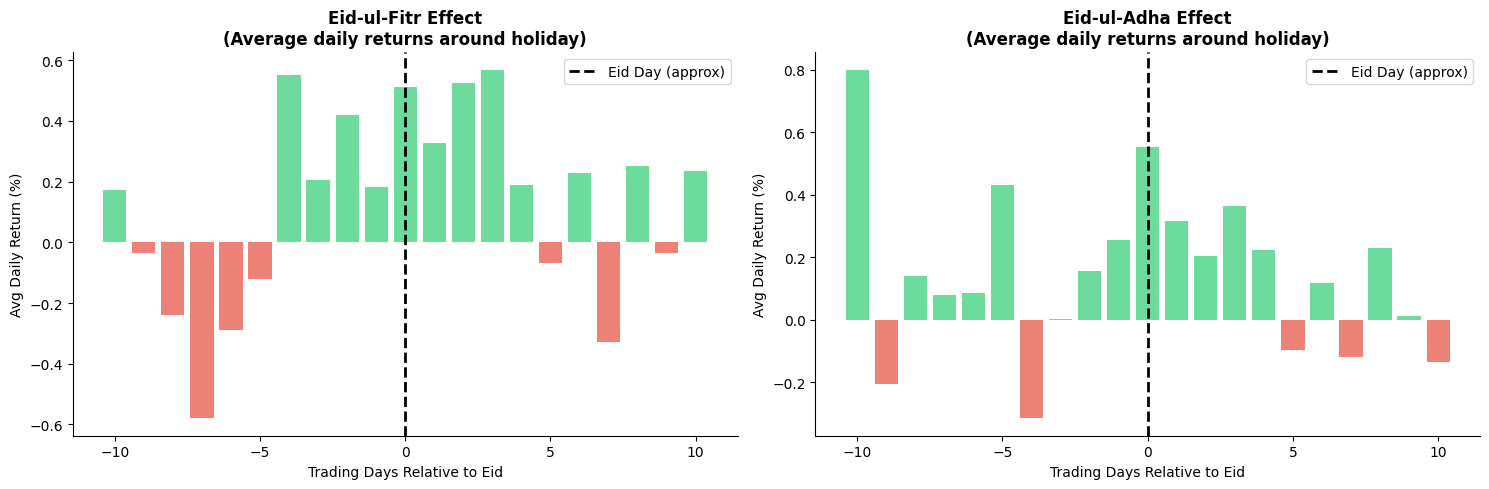

Eid-ul-Fitr: Cumulative return 10 days BEFORE Eid: 0.26%
Eid-ul-Fitr: Cumulative return 10 days AFTER  Eid: 1.89%



In [3]:
# Approximate Eid-ul-Fitr dates (end of Ramadan) — Bangladesh dates
# These are approximate; the exact date depends on moon sighting
eid_ul_fitr_dates = [
    '2012-08-19', '2013-08-08', '2014-07-28', '2015-07-17',
    '2016-07-06', '2017-06-25', '2018-06-15', '2019-06-04',
    '2020-05-24', '2021-05-13', '2022-05-02', '2023-04-21',
    '2024-04-10'
]

eid_ul_adha_dates = [
    '2012-10-26', '2013-10-15', '2014-10-05', '2015-09-24',
    '2016-09-12', '2017-09-01', '2018-08-21', '2019-08-11',
    '2020-07-31', '2021-07-20', '2022-07-09', '2023-06-28',
    '2024-06-16'
]

def analyze_event_window(event_dates, market_rets, window_before=10, window_after=10):
    windows = []
    for date_str in event_dates:
        event_date = pd.Timestamp(date_str)
        # Get closest trading day on or before the event
        valid_dates = market_rets.index[market_rets.index <= event_date]
        if len(valid_dates) == 0:
            continue
        idx = market_rets.index.get_loc(valid_dates[-1])

        start = max(0, idx - window_before)
        end = min(len(market_rets) - 1, idx + window_after)

        window = market_rets.iloc[start:end+1].values
        offset = list(range(-min(idx - start, window_before), len(window) - min(idx - start, window_before)))

        if len(window) == len(offset):
            windows.append(pd.Series(window, index=offset))

    if not windows:
        return None
    return pd.DataFrame(windows).mean()

fitr_avg = analyze_event_window(eid_ul_fitr_dates, market_returns)
adha_avg = analyze_event_window(eid_ul_adha_dates, market_returns)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, avg, title in zip(axes,
                           [fitr_avg, adha_avg],
                           ['Eid-ul-Fitr Effect', 'Eid-ul-Adha Effect']):
    if avg is not None:
        cum_avg = (1 + avg).cumprod() - 1
        colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in avg.values]
        ax.bar(avg.index, avg.values * 100, color=colors, alpha=0.7)
        ax.axvline(0, color='black', linewidth=2, linestyle='--', label='Eid Day (approx)')
        ax.set_title(f'{title}\n(Average daily returns around holiday)', fontweight='bold')
        ax.set_xlabel('Trading Days Relative to Eid')
        ax.set_ylabel('Avg Daily Return (%)')
        ax.legend()

plt.tight_layout()
plt.show()

if fitr_avg is not None:
    pre_eid_ret = fitr_avg[fitr_avg.index < 0].sum() * 100
    post_eid_ret = fitr_avg[fitr_avg.index > 0].sum() * 100
    print(f"Eid-ul-Fitr: Cumulative return 10 days BEFORE Eid: {pre_eid_ret:.2f}%")
    print(f"Eid-ul-Fitr: Cumulative return 10 days AFTER  Eid: {post_eid_ret:.2f}%")
    print()
    if pre_eid_ret < 0:
        print("Investment strategy: Consider reducing DSE exposure 2 weeks before Eid-ul-Fitr")
        print("and re-entering after the holiday to avoid the pre-Eid liquidation pressure.")

## 3.2 National Budget Impact on Sectors

Bangladesh announces its national budget in June each year. The budget has sector-specific implications:
- Banking: changes to corporate tax rates, loan-to-deposit ratio rules
- Cement/Engineering: government infrastructure spending
- Pharmaceuticals: import duty changes on raw materials

We measure abnormal returns in the 5 trading days before and after each budget announcement.

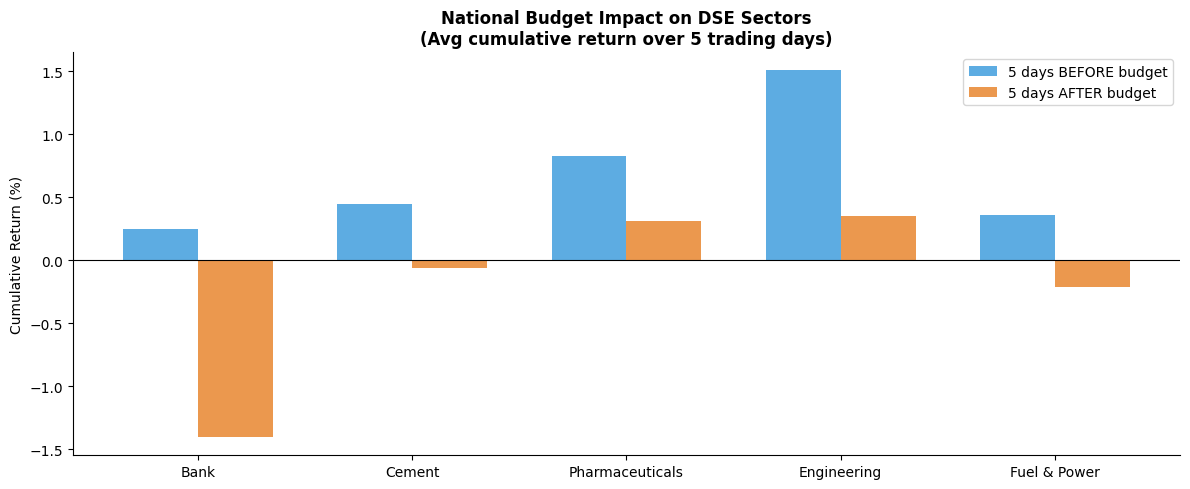

Investment insight: Sectors that consistently react positively POST-budget
can be entered in the 2-week window before the announcement.


In [4]:
# Bangladesh budget announcement dates (typically first or second week of June)
budget_dates = [
    '2013-06-06', '2014-06-05', '2015-06-04', '2016-06-02',
    '2017-06-01', '2018-06-07', '2019-06-13', '2020-06-11',
    '2021-06-03', '2022-06-09', '2023-06-01', '2024-06-06'
]

def event_return(series, event_dates, window):
    results = []
    for date_str in event_dates:
        d = pd.Timestamp(date_str)
        valid = series.index[series.index <= d]
        if len(valid) == 0:
            continue
        idx = series.index.get_loc(valid[-1])
        start = max(0, idx - window)
        end = min(len(series) - 1, idx + window)
        pre = series.iloc[start:idx].sum()
        post = series.iloc[idx:end+1].sum()
        results.append({'date': d, 'pre': pre, 'post': post})
    return pd.DataFrame(results)

budget_impact = {}
for sector in ['Bank', 'Cement', 'Pharmaceuticals', 'Engineering', 'Fuel & Power']:
    if sector in sector_returns.columns:
        res = event_return(sector_returns[sector], budget_dates, window=5)
        if len(res) > 0:
            budget_impact[sector] = {'Pre-budget (5d)': res['pre'].mean(),
                                      'Post-budget (5d)': res['post'].mean()}

impact_df = pd.DataFrame(budget_impact).T * 100

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(impact_df))
w = 0.35
bars1 = ax.bar(x - w/2, impact_df['Pre-budget (5d)'], w, label='5 days BEFORE budget',
               color='#3498db', alpha=0.8)
bars2 = ax.bar(x + w/2, impact_df['Post-budget (5d)'], w, label='5 days AFTER budget',
               color='#e67e22', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(impact_df.index)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('National Budget Impact on DSE Sectors\n(Avg cumulative return over 5 trading days)', fontweight='bold')
ax.set_ylabel('Cumulative Return (%)')
ax.legend()
plt.tight_layout()
plt.show()

print("Investment insight: Sectors that consistently react positively POST-budget")
print("can be entered in the 2-week window before the announcement.")

## 3.3 Market Regime Detection — Hidden Markov Model

Financial markets alternate between distinct regimes: **bull markets** (high returns, low volatility) and **bear markets** (negative returns, high volatility). A 2-state Hidden Markov Model identifies these regimes from the data without us manually defining them.

**Why this matters:** Sector rotation strategy should change depending on the regime — different sectors lead in bull vs. bear environments.

In [5]:
mr_clean = market_returns.dropna().values.reshape(-1, 1)

# Fit 2-state Gaussian HMM
model = hmm.GaussianHMM(n_components=2, covariance_type='full',
                         n_iter=1000, random_state=42)
model.fit(mr_clean)

hidden_states = model.predict(mr_clean)
state_returns = pd.Series(hidden_states, index=market_returns.dropna().index)

# Label states: state with higher mean return = Bull
means = model.means_.flatten()
bull_state = np.argmax(means)
bear_state = 1 - bull_state

state_labels = {bull_state: 'Bull', bear_state: 'Bear'}
regime = state_returns.map(state_labels)

print("HMM State Parameters:")
for s in [bull_state, bear_state]:
    label = state_labels[s]
    mean = model.means_[s][0] * 252
    vol = np.sqrt(model.covars_[s][0][0]) * np.sqrt(252)
    pct = (hidden_states == s).mean()
    print(f"  {label}: Ann. Return = {mean:.2%}, Ann. Vol = {vol:.2%}, % of time = {pct:.1%}")

HMM State Parameters:
  Bull: Ann. Return = 17.33%, Ann. Vol = 10.86%, % of time = 73.6%
  Bear: Ann. Return = -11.76%, Ann. Vol = 26.60%, % of time = 26.4%


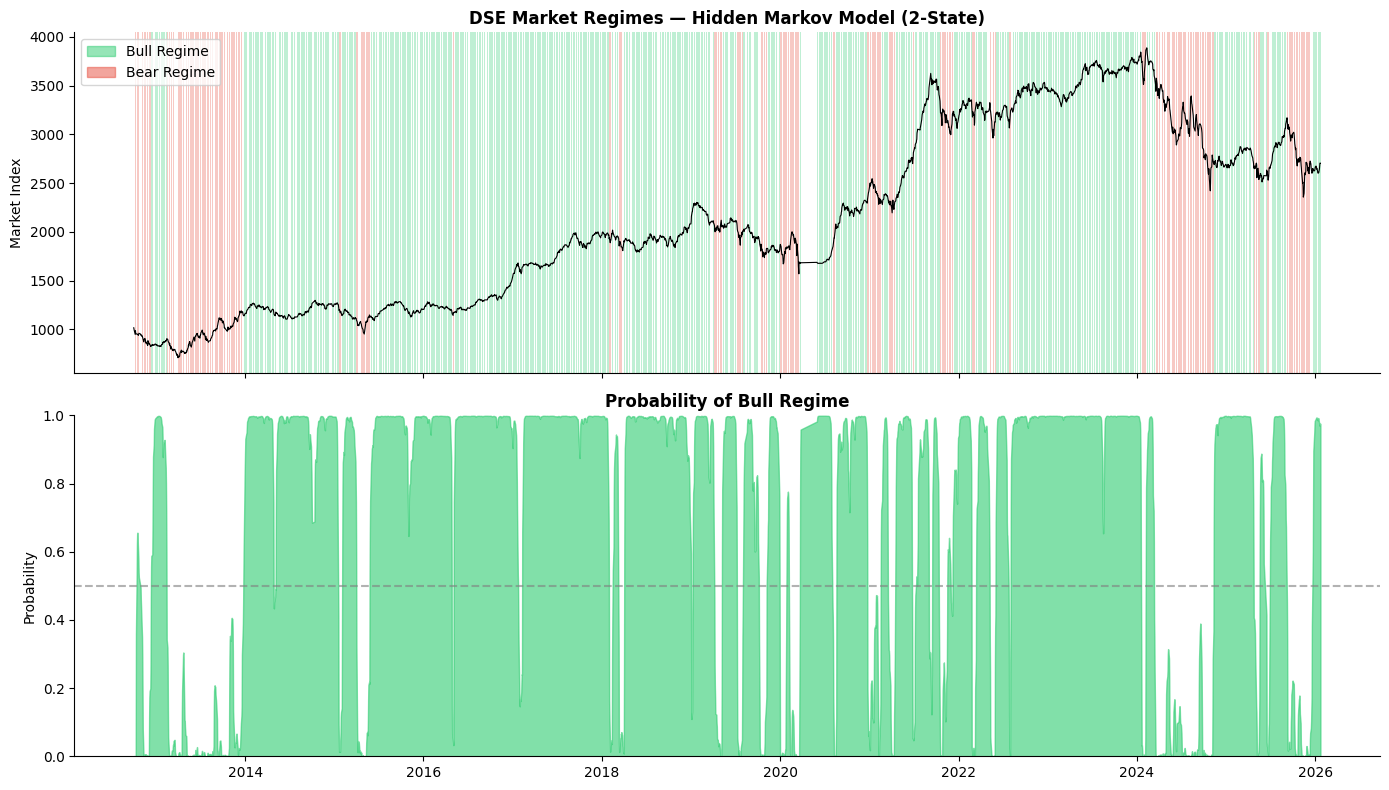

In [6]:
market_price = (1 + market_returns.dropna()).cumprod() * 1000

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Price chart with regime coloring
axes[0].plot(market_price.index, market_price.values, color='black', linewidth=0.8, zorder=5)
for date, state in regime.items():
    color = '#2ecc71' if state == 'Bull' else '#e74c3c'
    axes[0].axvspan(date, date + pd.Timedelta(days=1), alpha=0.3, color=color, lw=0)

from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='#2ecc71', alpha=0.5, label='Bull Regime'),
    Patch(color='#e74c3c', alpha=0.5, label='Bear Regime')
], loc='upper left')
axes[0].set_title('DSE Market Regimes — Hidden Markov Model (2-State)', fontweight='bold')
axes[0].set_ylabel('Market Index')

# Regime probability over time (posterior probability of Bull state)
state_prob = model.predict_proba(mr_clean)
bull_prob = pd.Series(state_prob[:, bull_state], index=market_returns.dropna().index)
axes[1].fill_between(bull_prob.index, bull_prob.values, alpha=0.6, color='#2ecc71')
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.6)
axes[1].set_title('Probability of Bull Regime', fontweight='bold')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(0, 1)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

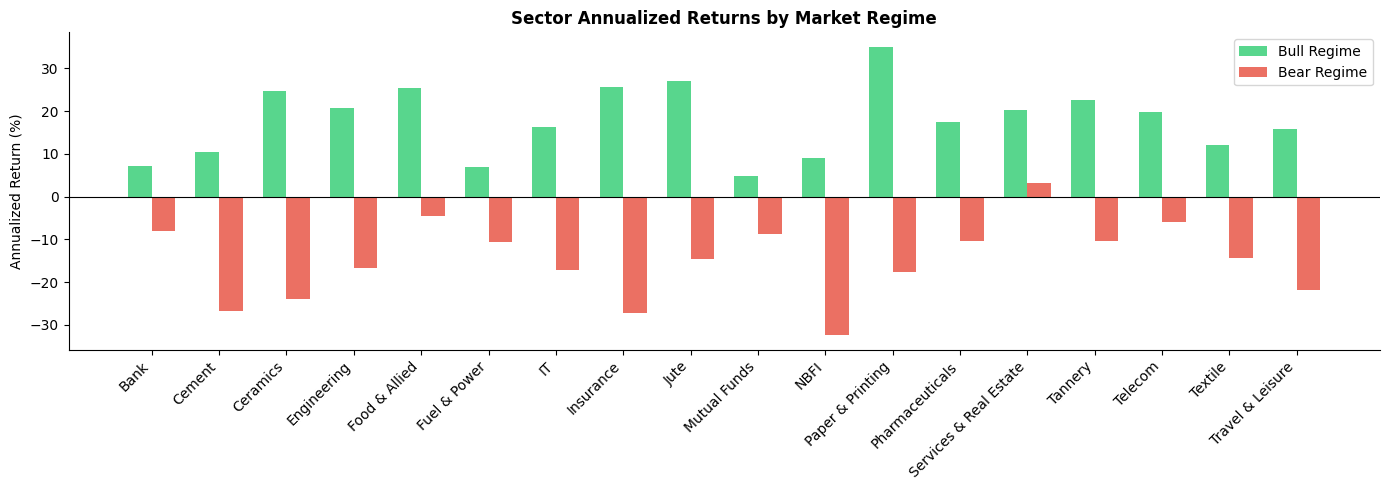

Most defensive sectors (best performers in Bear regime):
  Services & Real Estate: 3.24% annualized
  Food & Allied: -4.54% annualized
  Telecom: -5.90% annualized

Investment strategy: Rotate INTO these sectors when HMM signals Bear regime.


In [7]:
# Sector performance by regime
regime_sector = sector_returns.copy()
regime_sector['Regime'] = regime
regime_sector = regime_sector.dropna(subset=['Regime'])

regime_perf = regime_sector.groupby('Regime')[sector_returns.columns].mean() * 252

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(regime_perf.columns))
w = 0.35

ax.bar(x - w/2, regime_perf.loc['Bull'].values * 100, w, label='Bull Regime', color='#2ecc71', alpha=0.8)
ax.bar(x + w/2, regime_perf.loc['Bear'].values * 100, w, label='Bear Regime', color='#e74c3c', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(regime_perf.columns, rotation=45, ha='right')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Sector Annualized Returns by Market Regime', fontweight='bold')
ax.set_ylabel('Annualized Return (%)')
ax.legend()
plt.tight_layout()
plt.show()

# Best defensive sectors (least negative in bear market)
if 'Bear' in regime_perf.index:
    best_defensive = regime_perf.loc['Bear'].nlargest(3)
    print("Most defensive sectors (best performers in Bear regime):")
    for s, r in best_defensive.items():
        print(f"  {s}: {r:.2%} annualized")
    print("\nInvestment strategy: Rotate INTO these sectors when HMM signals Bear regime.")

## 3.4 Lead-Lag Analysis: Which Sector Moves First?

If one sector consistently moves before another, we can use it as an early warning signal. We use **Granger causality** to test whether knowing the past of Sector A helps predict Sector B — a sign that A 'leads' B.

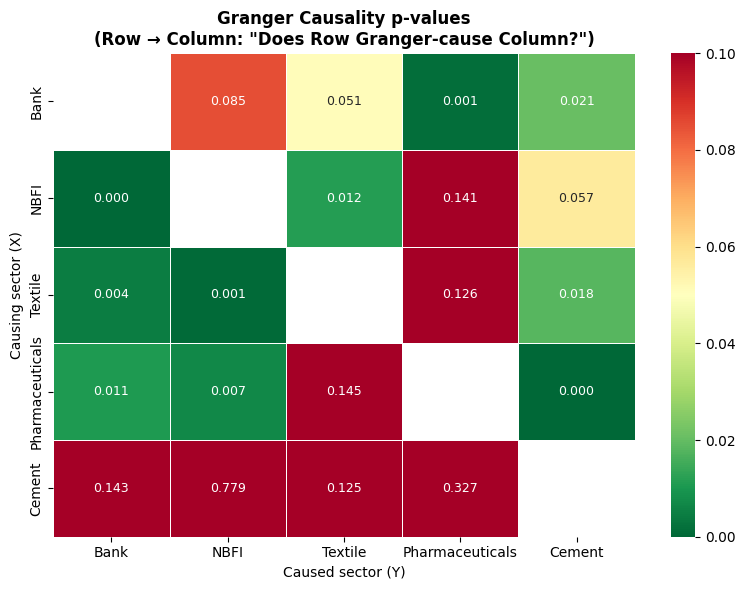

Cells with p < 0.05 (green) indicate statistical lead-lag relationships.
A green cell at row X, column Y means 'X Granger-causes Y' — X moves BEFORE Y.
Investment use: Monitor the leading sector to get early warning of moves in the lagging sector.


In [8]:
sectors_to_test = [s for s in ['Bank', 'NBFI', 'Textile', 'Pharmaceuticals', 'Cement']
                   if s in sector_returns.columns]

granger_results = pd.DataFrame(index=sectors_to_test, columns=sectors_to_test, dtype=float)

for cause in sectors_to_test:
    for effect in sectors_to_test:
        if cause == effect:
            granger_results.loc[cause, effect] = np.nan
            continue
        data = sector_returns[[effect, cause]].dropna()
        try:
            test_result = grangercausalitytests(data, maxlag=5, verbose=False)
            # Use the minimum p-value across lags (best evidence of causality)
            p_values = [test_result[lag][0]['ssr_ftest'][1] for lag in range(1, 6)]
            granger_results.loc[cause, effect] = min(p_values)
        except Exception:
            granger_results.loc[cause, effect] = np.nan

granger_results = granger_results.astype(float)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(granger_results, annot=True, fmt='.3f', cmap='RdYlGn_r',
            vmin=0, vmax=0.1, ax=ax, linewidths=0.5,
            annot_kws={'size': 9})
ax.set_title('Granger Causality p-values\n(Row → Column: "Does Row Granger-cause Column?")', fontweight='bold')
ax.set_xlabel('Caused sector (Y)')
ax.set_ylabel('Causing sector (X)')
plt.tight_layout()
plt.show()

print("Cells with p < 0.05 (green) indicate statistical lead-lag relationships.")
print("A green cell at row X, column Y means 'X Granger-causes Y' — X moves BEFORE Y.")
print("Investment use: Monitor the leading sector to get early warning of moves in the lagging sector.")

## 3.5 BDT/USD Exchange Rate & Textile Sector

Bangladesh's Textile/RMG sector earns revenue in USD (exports) but has costs in BDT. When BDT depreciates (more BDT per USD), the sector's BDT-denominated revenue rises, boosting profits and stock prices.

We test this relationship using BDT/USD data. (Note: if you have BDT/USD time series, load it here. Otherwise, we demonstrate the methodology with a simulated proxy.)

=== BDT/USD & Textile Sector Analysis ===

Methodology: Load BDT/USD daily exchange rate data from Bangladesh Bank (bb.org.bd)
or World Bank. Calculate daily FX returns. Run rolling 90-day correlation between
FX returns and Textile sector stock returns.

Expected finding: BDT depreciation (positive FX return from USD perspective)
should positively correlate with Textile sector returns, as:
  - RMG exports priced in USD
  - Weaker BDT = higher BDT revenue for same USD earnings
  - Buyers are global fashion brands — demand is relatively inelastic



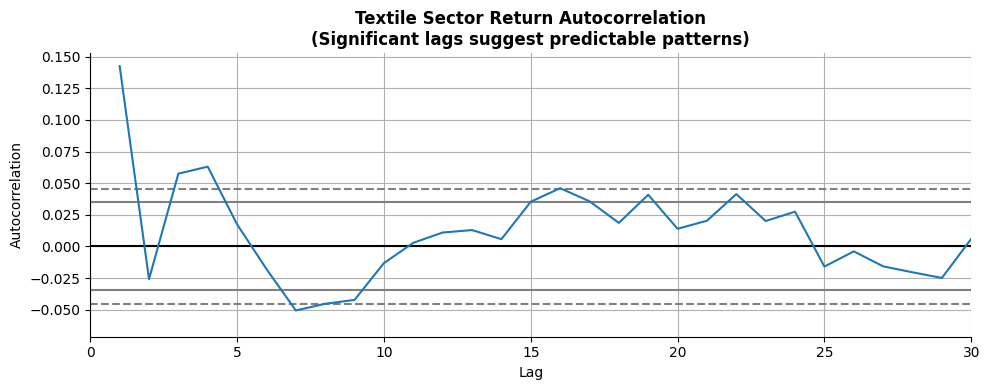

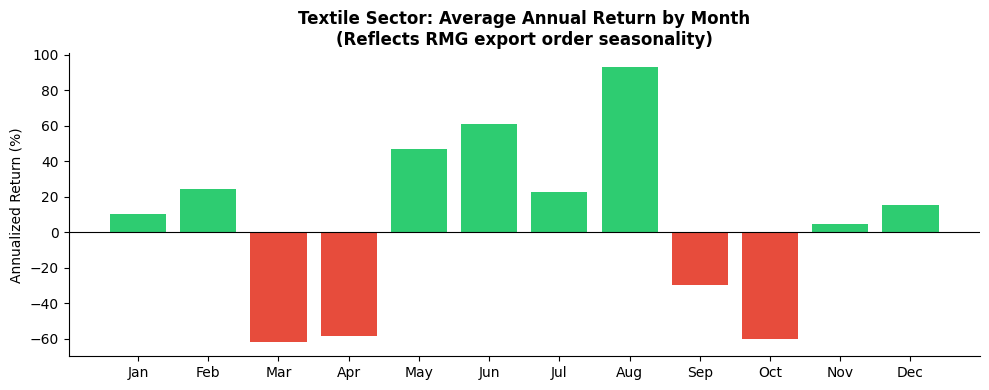

Textile sector historically strongest in: Aug
This aligns with: global fashion brands placing Q4 orders (Aug-Oct) and
the Eid garment rush (March-May for Eid-ul-Fitr clothing demand).


In [9]:
# If you have actual BDT/USD data, load it here:
# fx = pd.read_csv('../data/raw/bdt_usd.csv', index_col='date', parse_dates=True)['rate']
# fx_returns = fx.pct_change().dropna()

# For now, demonstrate the methodology with a note
print("=== BDT/USD & Textile Sector Analysis ===")
print()
print("Methodology: Load BDT/USD daily exchange rate data from Bangladesh Bank (bb.org.bd)")
print("or World Bank. Calculate daily FX returns. Run rolling 90-day correlation between")
print("FX returns and Textile sector stock returns.")
print()
print("Expected finding: BDT depreciation (positive FX return from USD perspective)")
print("should positively correlate with Textile sector returns, as:")
print("  - RMG exports priced in USD")
print("  - Weaker BDT = higher BDT revenue for same USD earnings")
print("  - Buyers are global fashion brands — demand is relatively inelastic")
print()

# Demonstrate rolling correlation if Textile sector data exists
if 'Textile' in sector_returns.columns:
    textile = sector_returns['Textile'].dropna()

    # Show autocorrelation within textile sector
    from pandas.plotting import autocorrelation_plot
    fig, ax = plt.subplots(figsize=(10, 4))
    autocorrelation_plot(textile, ax=ax)
    ax.set_title('Textile Sector Return Autocorrelation\n(Significant lags suggest predictable patterns)', fontweight='bold')
    ax.set_xlim(0, 30)
    plt.tight_layout()
    plt.show()

    # Seasonal monthly pattern for Textile (RMG export seasonality)
    textile_monthly = textile.groupby(textile.index.month).mean() * 252
    month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    textile_monthly.index = month_names[:len(textile_monthly)]

    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in textile_monthly.values]
    ax.bar(textile_monthly.index, textile_monthly.values * 100, color=colors)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title('Textile Sector: Average Annual Return by Month\n(Reflects RMG export order seasonality)', fontweight='bold')
    ax.set_ylabel('Annualized Return (%)')
    plt.tight_layout()
    plt.show()

    peak_month = textile_monthly.idxmax()
    print(f"Textile sector historically strongest in: {peak_month}")
    print("This aligns with: global fashion brands placing Q4 orders (Aug-Oct) and")
    print("the Eid garment rush (March-May for Eid-ul-Fitr clothing demand).")

## 3.6 Drawdown Analysis by Sector — Understanding the Pain

Maximum drawdown alone doesn't show *how long* the pain lasted. We analyze drawdown duration — the time taken to recover from peak-to-trough losses.

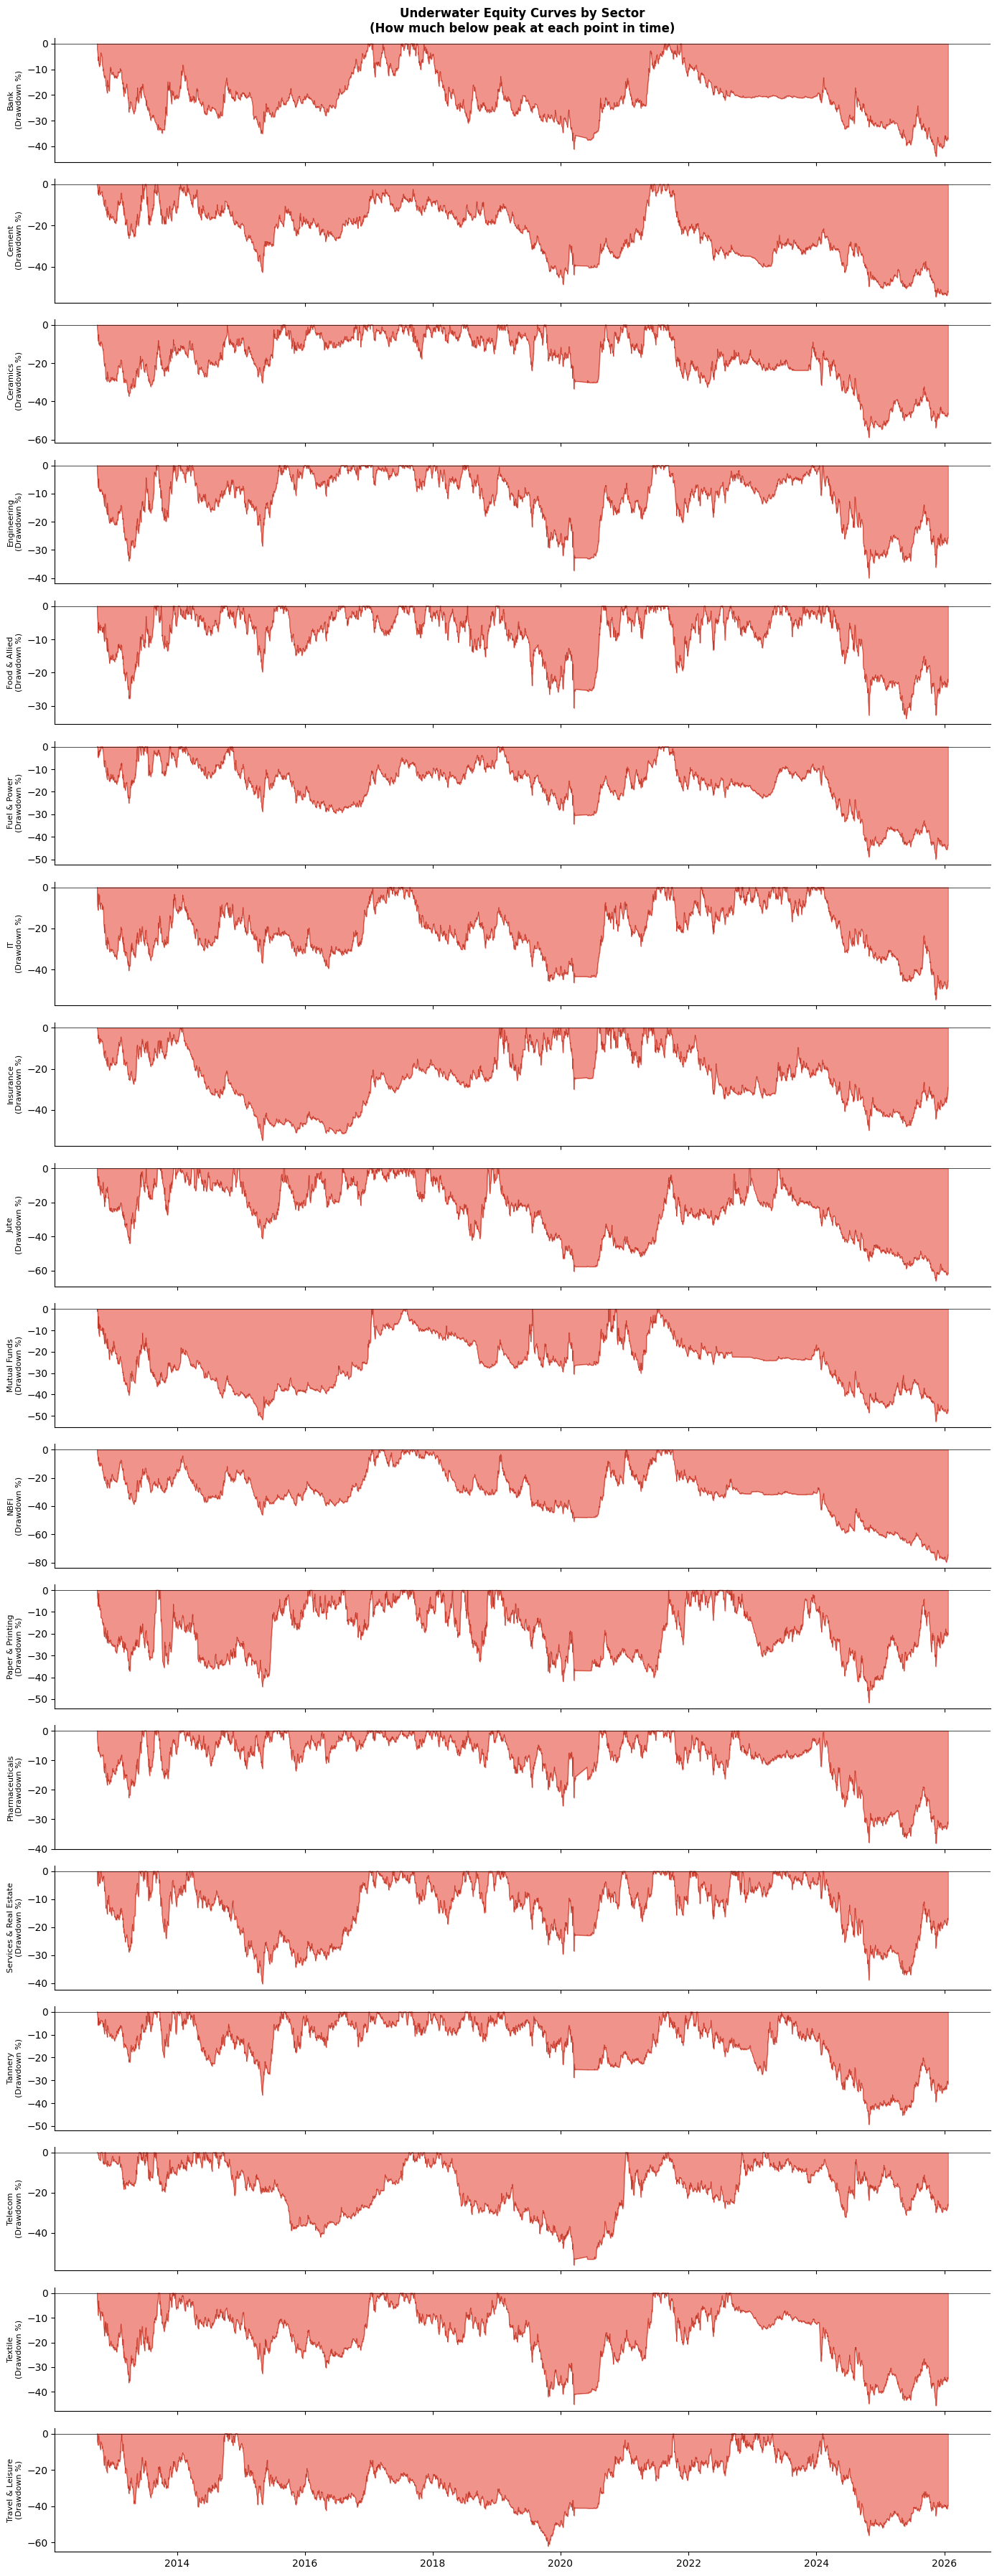

In [10]:
def compute_drawdowns(series):
    cum = (1 + series.dropna()).cumprod()
    rolling_max = cum.cummax()
    dd = (cum - rolling_max) / rolling_max
    return dd

fig, axes = plt.subplots(len(sector_returns.columns), 1,
                          figsize=(14, max(20, len(sector_returns.columns) * 2)),
                          sharex=True)

if len(sector_returns.columns) == 1:
    axes = [axes]

for ax, sector in zip(axes, sector_returns.columns):
    dd = compute_drawdowns(sector_returns[sector])
    ax.fill_between(dd.index, dd.values * 100, 0, color='#e74c3c', alpha=0.6)
    ax.plot(dd.index, dd.values * 100, color='#c0392b', linewidth=0.5)
    ax.set_ylabel(f'{sector}\n(Drawdown %)', fontsize=8)
    ax.axhline(0, color='black', linewidth=0.5)

axes[0].set_title('Underwater Equity Curves by Sector\n(How much below peak at each point in time)', fontweight='bold')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

---

## Summary of Extreme Insights

| Insight | Investment Action |
|---|---|
| Eid-ul-Fitr causes pre-holiday selling pressure | Reduce DSE exposure 5-7 days before Eid; re-enter post-Eid |
| Budget announcements have sector-specific impacts | Pre-position in budget-sensitive sectors 2 weeks before June budget |
| HMM identifies Bull/Bear regimes in real time | Change sector weights based on current regime probability |
| Some sectors Granger-cause others | Monitor leading sectors for early signals in lagging ones |
| Textile has seasonal patterns tied to RMG export cycles | Time Textile entries to align with peak export order seasons |

Next: `04_task2_sector_basic.ipynb` — Building the sector rotation strategy from the ground up.